In [1]:
# pip install prophet
import pandas as pd
from prophet import Prophet

# Python - This data is measuring the average page visits for 
# Peyton Manning's wikipedia page on different time periods
df = pd.read_csv('https://raw.githubusercontent.com/facebook/prophet/main/examples/example_wp_log_peyton_manning.csv')
df.head()

c:\Users\tuomas.valtanen\introtoml2026lectures\IntroductionToML2026\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


,ds,y
0,2007-12-10,9.590761
1,2007-12-11,8.519590
2,2007-12-12,8.183677
3,2007-12-13,8.072467
4,2007-12-14,7.893572


In [2]:
# Python
m = Prophet()
m.fit(df)

10:17:59 - cmdstanpy - INFO - Chain [1] start processing
10:18:00 - cmdstanpy - INFO - Chain [1] done processing


<Axes: >

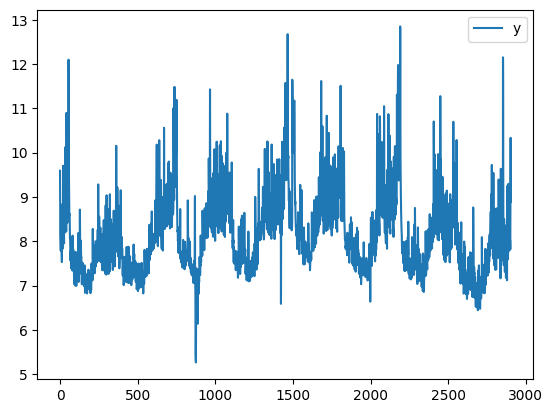

In [3]:
# there seems to be some trends and cycles in the data
df.plot()

In [ ]:
# predict to the "future"
future = m.make_future_dataframe(periods=365)
future.tail()

,ds
3265,2017-01-15
3266,2017-01-16
3267,2017-01-17
3268,2017-01-18
3269,2017-01-19


In [5]:
# Python
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
3265,2017-01-15,8.206966,7.488192,8.912079
3266,2017-01-16,8.531961,7.808006,9.286753
3267,2017-01-17,8.319378,7.568784,9.033597
3268,2017-01-18,8.151994,7.392626,8.889814
3269,2017-01-19,8.163910,7.412030,8.911825


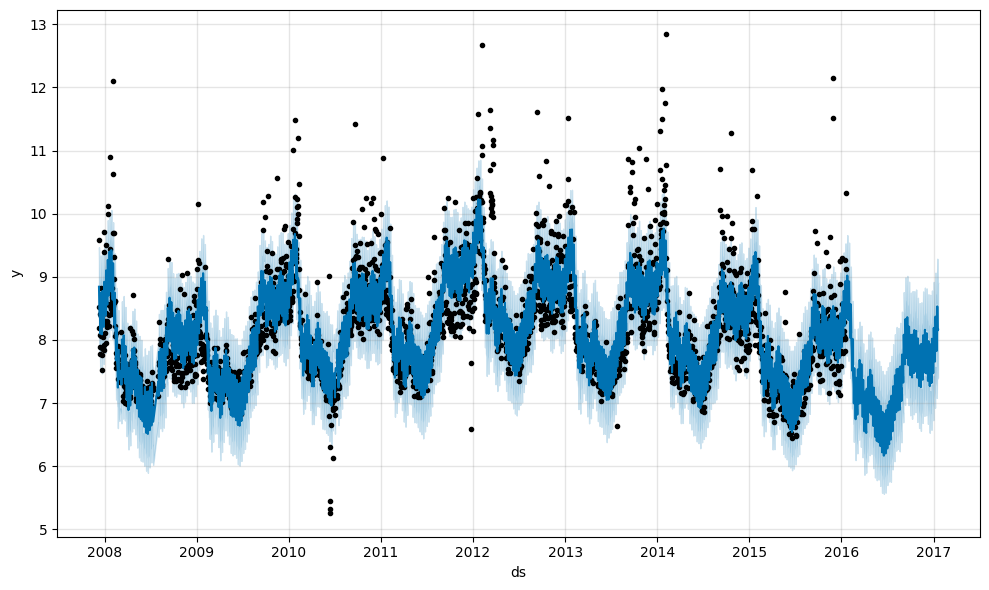

In [ ]:
# Python
fig1 = m.plot(forecast)

# the black dots are samples from the real training data
# the dark blue line is the average prediction of the trend
# and light shades around the dark blue line are the confidence interval
# it seems the model is quite conservative in the predictions, 
# since the real values are much higher than even the confidence interval
# the prediction into the future seems to go steadily down
# probably due to this player no longer being active in NFL?
# (Peyton Manning was/is an NFL player, American Football)

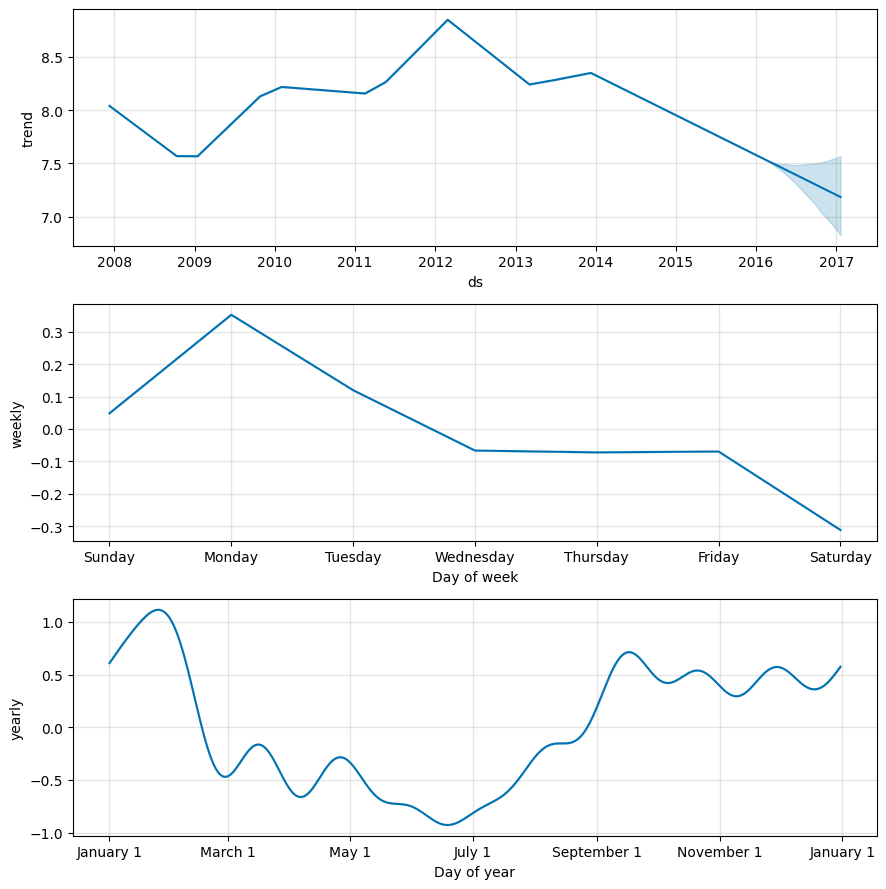

In [7]:
# show also the components of the plot
fig2 = m.plot_components(forecast)

# we can see the overall trend going downwards
# Monday seems to be the day of highest activity (probably after weekend, when a game was played?)

# and popularity peaks in February (Super Bowl), and starts rising 
# in September (start of new NFL season)